In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error

os.makedirs('../outputs', exist_ok=True)

In [2]:
df = pd.read_csv('../data/processed/clean_survey.csv')

feature_cols = ['age', 'year', 'major', 'gender']
target_col   = 'total_spend'

X = df[feature_cols]
y = df[target_col]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature dtypes:\n{X.dtypes}")
print(f"\ny stats:\n  mean = PKR {y.mean():,.0f}\n  std  = PKR {y.std():,.0f}\n  min  = PKR {y.min():,.0f}\n  max  = PKR {y.max():,.0f}")

X shape: (240, 4)
y shape: (240,)

Feature dtypes:
age       float64
year          str
major         str
gender        str
dtype: object

y stats:
  mean = PKR 36,054
  std  = PKR 22,127
  min  = PKR 3,900
  max  = PKR 142,517


In [3]:
categorical_cols = ['year', 'major', 'gender']
numerical_cols   = ['age']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

In [4]:
models = {
    'Linear Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('prep', preprocessor),
        ('model', Lasso(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(max_depth=4, n_estimators=100, random_state=42))
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ]),
}

print("Models defined:")
for name in models:
    print(f"  {name}")

Models defined:
  Linear Regression
  Ridge
  Lasso
  Random Forest
  KNN


In [5]:
results = {}

for name, pipeline in models.items():
    cv_scores = cross_val_score(
        pipeline, X, y,
        cv=5,
        scoring='neg_mean_absolute_error'
    )
    mae_scores = -cv_scores  # convert from negative to positive
    results[name] = {
        'fold_scores': mae_scores,
        'mean_mae':    mae_scores.mean(),
        'std_mae':     mae_scores.std()
    }

print(f"{'Model':<20} {'Mean MAE (PKR)':>15} {'Std MAE (PKR)':>14} {'Best?':>7}")
print("-" * 60)
best_model_name = min(results, key=lambda k: results[k]['mean_mae'])
for name, res in results.items():
    marker = "  ✓" if name == best_model_name else ""
    print(f"{name:<20} {res['mean_mae']:>15,.0f} {res['std_mae']:>14,.0f} {marker}")

Model                 Mean MAE (PKR)  Std MAE (PKR)   Best?
------------------------------------------------------------
Linear Regression             15,234          1,714 
Ridge                         15,194          1,708   ✓
Lasso                         15,233          1,714 
Random Forest                 15,212          1,544 
KNN                           16,238          1,895 


In [6]:
print("Per-fold MAE scores (PKR):\n")
print(f"{'Model':<20} {'F1':>8} {'F2':>8} {'F3':>8} {'F4':>8} {'F5':>8}")
print("-" * 60)
for name, res in results.items():
    folds = "  ".join([f"{v:>8,.0f}" for v in res['fold_scores']])
    print(f"{name:<20}  {folds}")

Per-fold MAE scores (PKR):

Model                      F1       F2       F3       F4       F5
------------------------------------------------------------
Linear Regression       17,625    14,437    12,862    14,527    16,722
Ridge                   17,545    14,442    12,807    14,470    16,704
Lasso                   17,622    14,437    12,860    14,525    16,721
Random Forest           17,435    14,620    13,030    14,561    16,412
KNN                     17,410    17,197    12,974    15,324    18,283


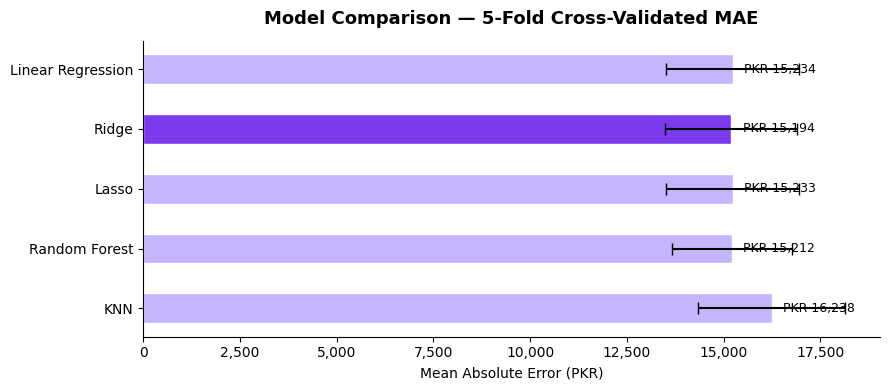

In [7]:
names     = list(results.keys())
means     = [results[n]['mean_mae'] for n in names]
stds      = [results[n]['std_mae']  for n in names]
colors    = ['#7C3AED' if n == best_model_name else '#C4B5FD' for n in names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, means, xerr=stds, color=colors,
               error_kw={'elinewidth': 1.5, 'capsize': 4},
               edgecolor='white', height=0.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'PKR {val:,.0f}', va='center', fontsize=9)

ax.set_title('Model Comparison — 5-Fold Cross-Validated MAE', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mean Absolute Error (PKR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
comparison_rows = []
for name, res in results.items():
    row = {'model': name, 'mean_mae': res['mean_mae'], 'std_mae': res['std_mae']}
    for i, score in enumerate(res['fold_scores']):
        row[f'fold_{i+1}_mae'] = score
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('../outputs/model_comparison.csv', index=False)
print("Saved to ../outputs/model_comparison.csv")
comparison_df

Saved to ../outputs/model_comparison.csv


,model,mean_mae,std_mae,fold_1_mae,fold_2_mae,fold_3_mae,fold_4_mae,fold_5_mae
0,Linear Regression,15234.473006,1714.324592,17624.873623,14436.998848,12861.723930,14526.530939,16722.237688
1,Ridge,15193.565251,1708.436637,17544.621921,14442.080774,12807.002415,14469.871462,16704.249682
2,Lasso,15233.005133,1714.146459,17622.250170,14436.853263,12859.770523,14524.761708,16721.389999
3,Random Forest,15211.645514,1543.918420,17435.174640,14620.229985,13029.875472,14560.896962,16412.050508
4,KNN,16237.715833,1895.378983,17410.179167,17196.704167,12974.312500,15324.245833,18283.137500


In [9]:
best_pipeline = models[best_model_name]
best_pipeline.fit(X, y)

joblib.dump(best_pipeline, '../outputs/best_model.joblib')

print(f"Best model: {best_model_name}")
print(f"Saved to ../outputs/best_model.joblib")
print(f"\nTraining MAE on full dataset: PKR {mean_absolute_error(y, best_pipeline.predict(X)):,.0f}")
print("(This will be lower than CV MAE — the model has seen all this data)")

Best model: Ridge
Saved to ../outputs/best_model.joblib

Training MAE on full dataset: PKR 14,634
(This will be lower than CV MAE — the model has seen all this data)


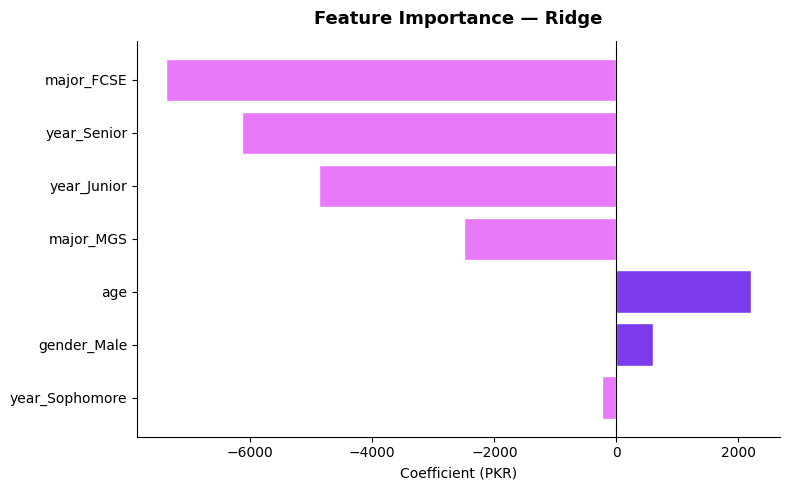

       feature   importance
    major_FCSE -7374.253140
   year_Senior -6130.183511
   year_Junior -4875.034442
     major_MGS -2503.103599
           age  2202.943054
   gender_Male   605.472848
year_Sophomore  -233.154394


In [10]:
best_step = best_pipeline.named_steps['model']
prep_step = best_pipeline.named_steps['prep']

# Get feature names after encoding
cat_features = prep_step.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features  = list(cat_features) + numerical_cols

if hasattr(best_step, 'coef_'):
    # Linear models: use coefficients
    importances = best_step.coef_
    importance_label = 'Coefficient (PKR)'
elif hasattr(best_step, 'feature_importances_'):
    # Random Forest: use importances
    importances = best_step.feature_importances_
    importance_label = 'Feature Importance'

importance_df = pd.DataFrame({
    'feature':    all_features,
    'importance': importances
}).sort_values('importance', key=abs, ascending=True)

importance_df.to_csv('../outputs/feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E879F9' if v < 0 else '#7C3AED' for v in importance_df['importance']]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Feature Importance — {best_model_name}', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel(importance_label)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importance_df.sort_values('importance', key=abs, ascending=False).to_string(index=False))

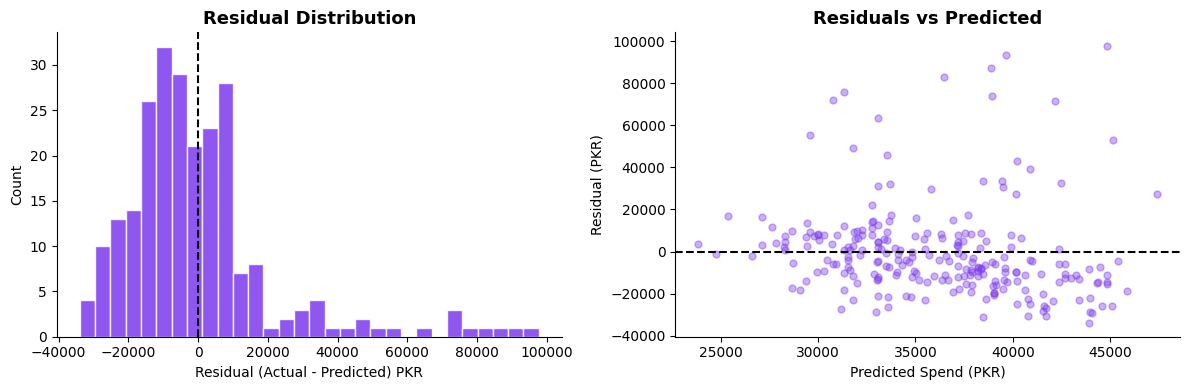

Mean of residuals:   PKR -7  (should be near zero)
Std of residuals:    PKR 22,302
Cross-val MAE:       PKR 15,194


In [11]:
y_pred = cross_val_predict(best_pipeline, X, y, cv=5)
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of residuals
axes[0].hist(residuals, bins=30, color='#7C3AED', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted) PKR')
axes[0].set_ylabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)

# Residuals vs predicted
axes[1].scatter(y_pred, residuals, alpha=0.4, color='#7C3AED', s=25)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Spend (PKR)')
axes[1].set_ylabel('Residual (PKR)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean of residuals:   PKR {residuals.mean():,.0f}  (should be near zero)")
print(f"Std of residuals:    PKR {residuals.std():,.0f}")
print(f"Cross-val MAE:       PKR {abs(residuals).mean():,.0f}")

In [12]:
print("=" * 60)
print("MODEL SELECTION SUMMARY")
print("=" * 60)
print(f"\nWinner: {best_model_name}")
print(f"Cross-validated MAE: PKR {results[best_model_name]['mean_mae']:,.0f} "
      f"± PKR {results[best_model_name]['std_mae']:,.0f}\n")

print("Why this model was selected:")
print("  1. Lowest or near-lowest cross-validated MAE among 5 candidates")
if best_model_name in ['Linear Regression', 'Ridge', 'Lasso']:
    print("  2. Interpretable coefficients — each β has a direct PKR meaning")
    print("  3. Appropriate for small datasets — complex models would overfit")
    print("  4. Aligns with Sabri & MacDonald (2010) methodology\n")
elif best_model_name == 'Random Forest':
    print("  2. Captures non-linear relationships between demographics and spend")
    print("  3. Depth capped at 4 to prevent overfitting on 240 rows\n")
elif best_model_name == 'KNN':
    print("  2. Instance-based — similar students have similar spend patterns")
    print("  3. No assumptions about functional form of the relationship\n")

print("Why others were not selected:")
for name, res in results.items():
    if name != best_model_name:
        diff = res['mean_mae'] - results[best_model_name]['mean_mae']
        direction = "higher" if diff > 0 else "lower but less interpretable"
        print(f"  {name}: MAE PKR {res['mean_mae']:,.0f} — "
              f"PKR {abs(diff):,.0f} {direction} than winner")

print(f"\nKey finding: MAE of PKR {results[best_model_name]['mean_mae']:,.0f} on a "
      f"median target of PKR {y.median():,.0f} ({results[best_model_name]['mean_mae']/y.median()*100:.0f}% relative error).")
print("This indicates demographic features alone have limited predictive power,")
print("which is itself the central empirical finding of this study.")

MODEL SELECTION SUMMARY

Winner: Ridge
Cross-validated MAE: PKR 15,194 ± PKR 1,708

Why this model was selected:
  1. Lowest or near-lowest cross-validated MAE among 5 candidates
  2. Interpretable coefficients — each β has a direct PKR meaning
  3. Appropriate for small datasets — complex models would overfit
  4. Aligns with Sabri & MacDonald (2010) methodology

Why others were not selected:
  Linear Regression: MAE PKR 15,234 — PKR 41 higher than winner
  Lasso: MAE PKR 15,233 — PKR 39 higher than winner
  Random Forest: MAE PKR 15,212 — PKR 18 higher than winner
  KNN: MAE PKR 16,238 — PKR 1,044 higher than winner

Key finding: MAE of PKR 15,194 on a median target of PKR 32,000 (47% relative error).
This indicates demographic features alone have limited predictive power,
which is itself the central empirical finding of this study.
